In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os
import cv2

In [2]:
BASE_DIR=r"D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-vs-fake"

In [3]:
def load_data(split):
    data=[]
    VALID_EXT=(".jpg", ".jpeg", ".png")
    for label in ["real","fake"]:
        folder=os.path.join(BASE_DIR,split,label)
        for img in os.listdir(folder):
            if img.lower().endswith(VALID_EXT):
                data.append({"path":os.path.join(folder,img),"label":label})

    return pd.DataFrame(data)

In [4]:
train_df=load_data("train")
test_df=load_data("test")
val_df=load_data("valid")

In [5]:
print(train_df.head())
print(train_df["label"].value_counts())

                                                path label
0  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
1  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
2  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
3  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
4  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
label
real    50000
fake    50000
Name: count, dtype: int64


In [6]:
print(test_df.head())
print(test_df["label"].value_counts())

                                                path label
0  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
1  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
2  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
3  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
4  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
label
real    10000
fake    10000
Name: count, dtype: int64


In [7]:
print(val_df.head())
print(val_df["label"].value_counts())

                                                path label
0  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
1  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
2  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
3  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
4  D:\SEM-6\DL\DEEP-FAKE\DataSets\140k_main\real-...  real
label
real    10000
fake    10000
Name: count, dtype: int64


In [8]:
print("Train:", train_df.shape)
print("Valid:", val_df.shape)
print("Test :", test_df.shape)

Train: (100000, 2)
Valid: (20000, 2)
Test : (20000, 2)


In [9]:
def resolution_eda(df, name, plot_sample=4000):

    widths=np.empty(len(df), dtype=np.int32)
    heights=np.empty(len(df), dtype=np.int32)

    bad=0

    for i, path in enumerate(tqdm(df["path"], desc=f"{name} scan")):
        try:
            with Image.open(path) as img:
                w, h = img.size
        except:
            w, h = -1, -1
            bad += 1

        widths[i]=w
        heights[i]=h

    df = df.copy()
    df["width"]=widths
    df["height"]=heights

    df=df[df["width"] > 0]

    print(f"\n{name} corrupted images:", bad)

    print(f"\n{name} resolution statistics:")
    print(df[["width", "height"]].describe())

    if len(df) > plot_sample:
        plot_df = df.sample(plot_sample, random_state=42)
    else:
        plot_df = df

    plt.figure(figsize=(6,5))
    plt.scatter(
        plot_df["width"],
        plot_df["height"],
        s=4,
        alpha=0.3
    )
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title(f"{name} Resolution Distribution")
    plt.show()

    return df


Train scan: 100%|██████████| 100000/100000 [23:47<00:00, 70.06it/s]



Train corrupted images: 0

Train resolution statistics:
          width    height
count  100000.0  100000.0
mean      256.0     256.0
std         0.0       0.0
min       256.0     256.0
25%       256.0     256.0
50%       256.0     256.0
75%       256.0     256.0
max       256.0     256.0


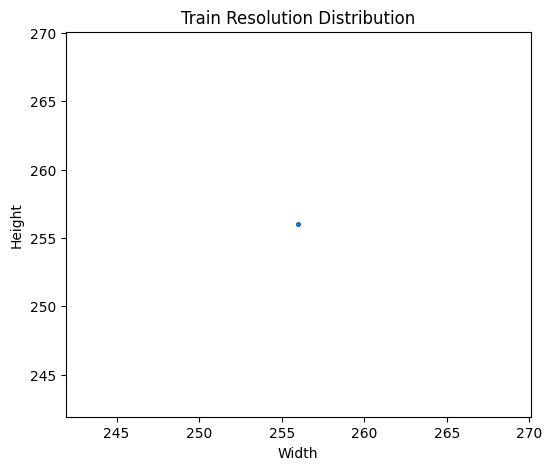

Validation scan: 100%|██████████| 20000/20000 [04:45<00:00, 69.98it/s]


Validation corrupted images: 0

Validation resolution statistics:
         width   height
count  20000.0  20000.0
mean     256.0    256.0
std        0.0      0.0
min      256.0    256.0
25%      256.0    256.0
50%      256.0    256.0
75%      256.0    256.0
max      256.0    256.0


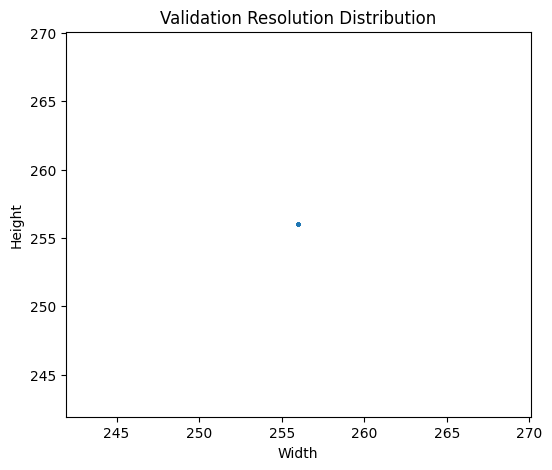

Test scan: 100%|██████████| 20000/20000 [04:53<00:00, 68.10it/s]


Test corrupted images: 0

Test resolution statistics:
         width   height
count  20000.0  20000.0
mean     256.0    256.0
std        0.0      0.0
min      256.0    256.0
25%      256.0    256.0
50%      256.0    256.0
75%      256.0    256.0
max      256.0    256.0


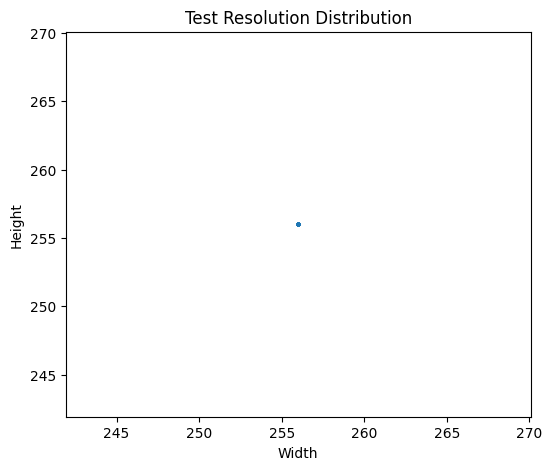

In [10]:
train_res = resolution_eda(train_df, "Train")
val_res   = resolution_eda(val_df, "Validation")
test_res  = resolution_eda(test_df, "Test")


In [11]:
def aspect_ratio_eda(res_df, name):

    res_df["aspect_ratio"] = res_df["width"] / res_df["height"]

    sns.histplot(res_df["aspect_ratio"], bins=50)
    plt.title(f"{name} Aspect Ratio Distribution")
    plt.show()

    print(res_df["aspect_ratio"].describe())


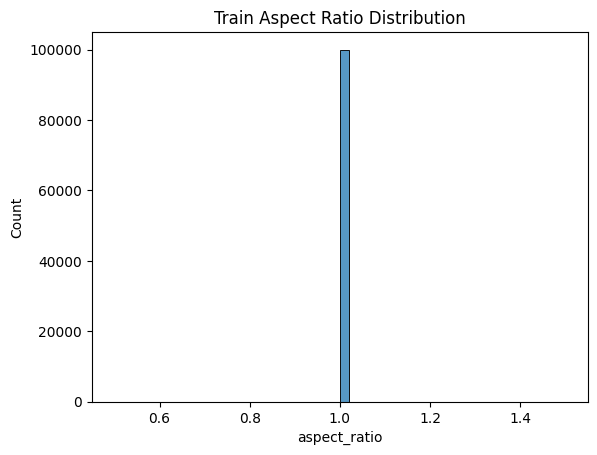

count    100000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: aspect_ratio, dtype: float64


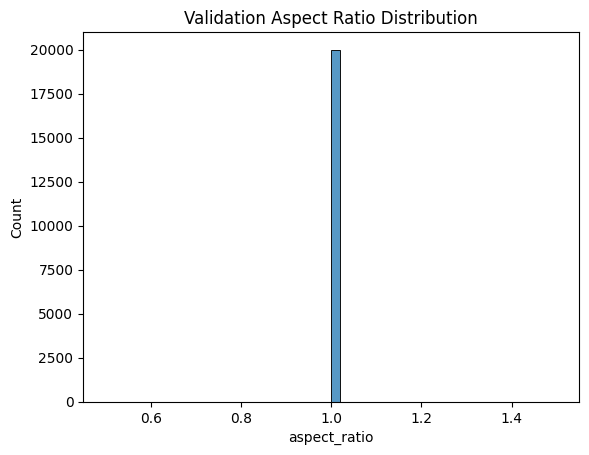

count    20000.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: aspect_ratio, dtype: float64


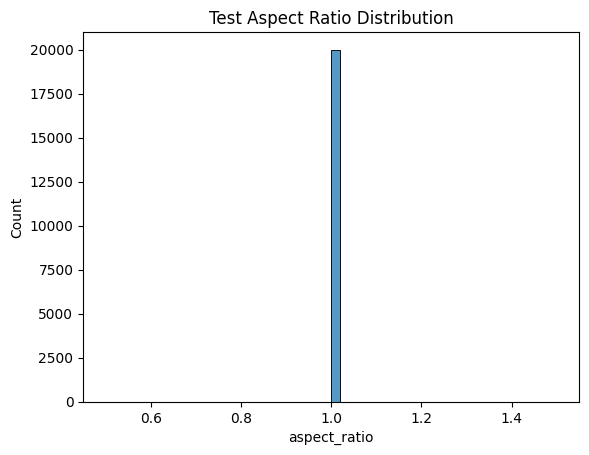

count    20000.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: aspect_ratio, dtype: float64


In [12]:
aspect_ratio_eda(train_res, "Train")
aspect_ratio_eda(val_res, "Validation")
aspect_ratio_eda(test_res, "Test")


In [13]:
def brightness_contrast_eda(df, name, sample=4000):

    temp = df.sample(sample, random_state=42)

    brightness = []
    contrast   = []

    for path in tqdm(temp["path"], desc=f"{name} brightness"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        brightness.append(img.mean())
        contrast.append(img.std())

    temp["brightness"] = brightness
    temp["contrast"]   = contrast

    sns.kdeplot(data=temp, x="brightness", hue="label", fill=True)
    plt.title(f"{name} Brightness Distribution")
    plt.show()

    sns.kdeplot(data=temp, x="contrast", hue="label", fill=True)
    plt.title(f"{name} Contrast Distribution")
    plt.show()

Train brightness: 100%|██████████| 4000/4000 [00:04<00:00, 896.85it/s] 


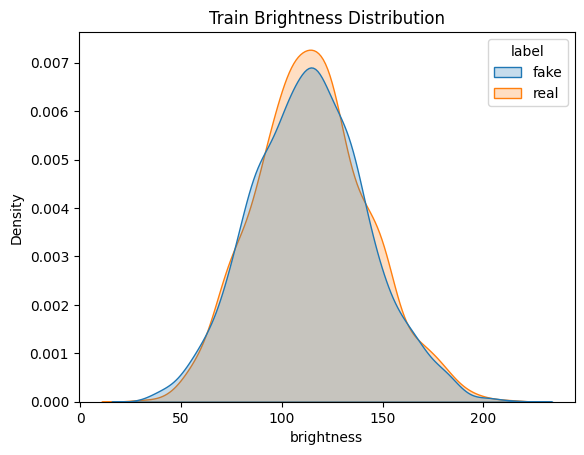

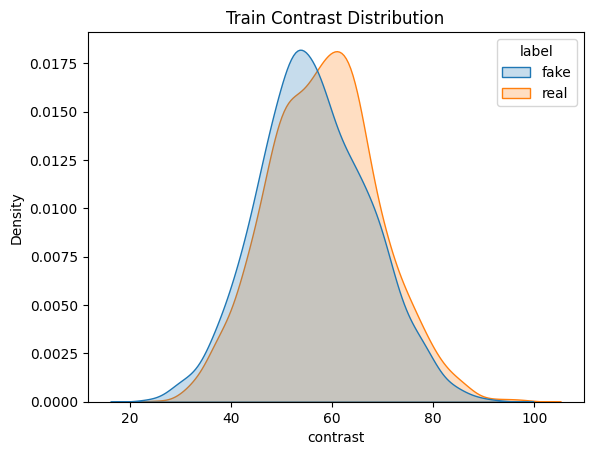

Validation brightness: 100%|██████████| 4000/4000 [00:06<00:00, 638.04it/s]


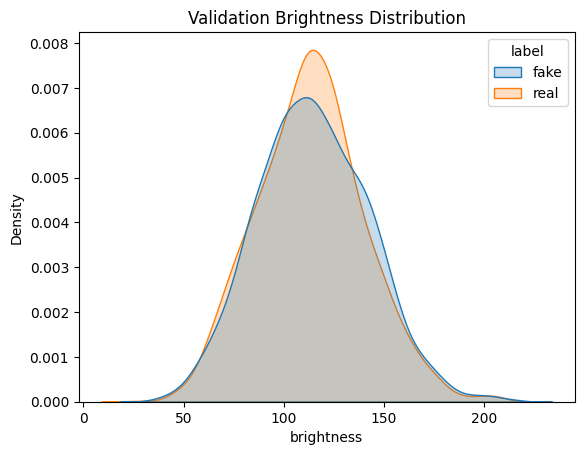

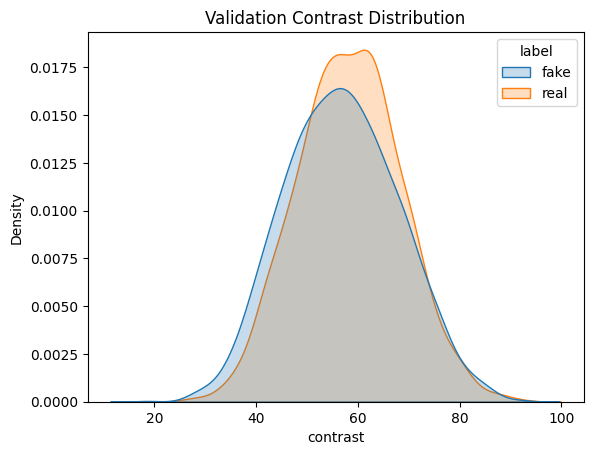

Test brightness: 100%|██████████| 4000/4000 [00:05<00:00, 733.25it/s]


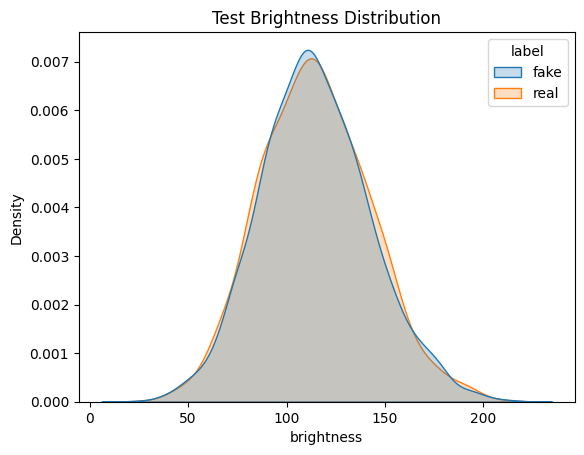

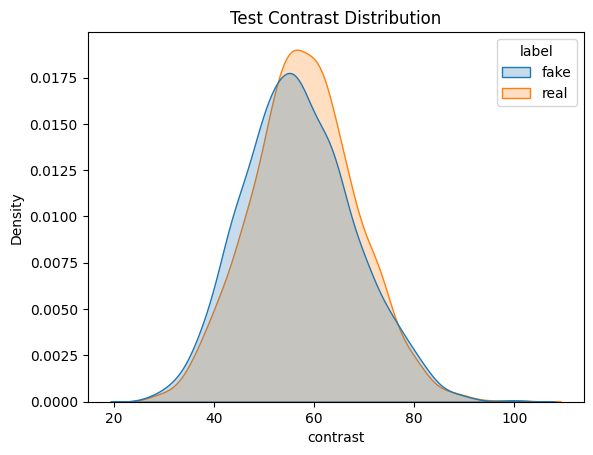

In [14]:
brightness_contrast_eda(train_df, "Train")
brightness_contrast_eda(val_df, "Validation")
brightness_contrast_eda(test_df, "Test")

In [15]:
def rgb_channel_eda(df, name, sample=4000):

    temp = df.sample(sample, random_state=42)

    R, G, B = [], [], []

    for path in tqdm(temp["path"], desc=f"{name} RGB"):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r, g, b = img.mean(axis=(0,1))
        R.append(r); G.append(g); B.append(b)

    plt.figure(figsize=(8,5))
    sns.kdeplot(R, label="R")
    sns.kdeplot(G, label="G")
    sns.kdeplot(B, label="B")
    plt.title(f"{name} RGB Channel Means")
    plt.legend()
    plt.show()

Train RGB: 100%|██████████| 4000/4000 [00:06<00:00, 584.64it/s]


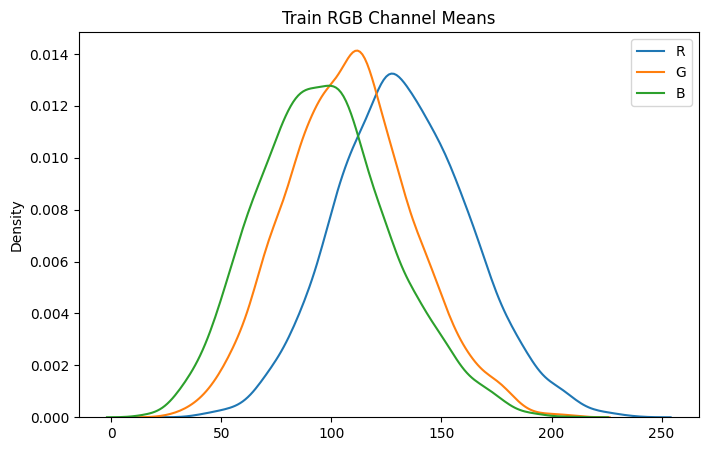

Validate RGB: 100%|██████████| 4000/4000 [00:06<00:00, 659.87it/s]


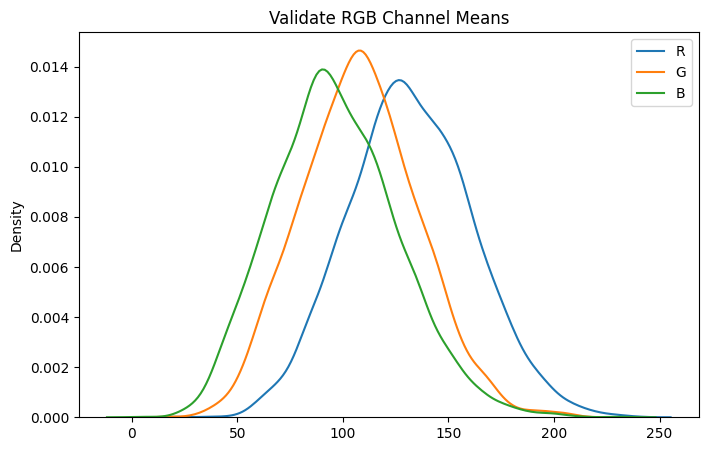

Test RGB: 100%|██████████| 4000/4000 [00:05<00:00, 797.20it/s]


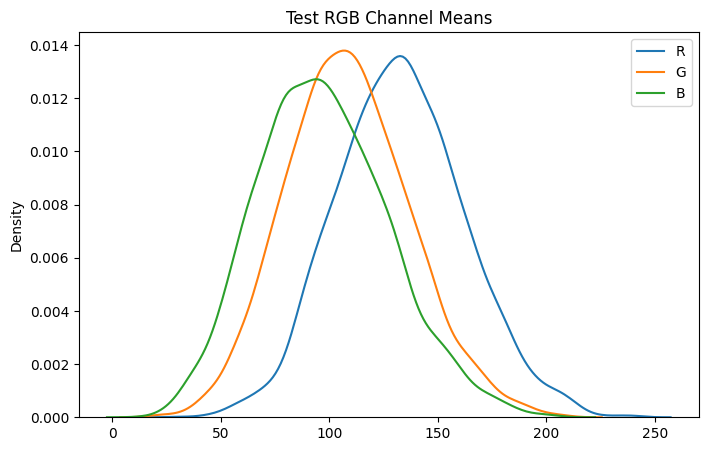

In [16]:
rgb_channel_eda(train_df,"Train")
rgb_channel_eda(val_df,"Validate")
rgb_channel_eda(test_df,"Test")

In [17]:
def fft_energy_eda(df, name, sample=2000):

    temp = df.sample(sample, random_state=42)

    def fft_energy(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256,256))
        f = np.fft.fftshift(np.fft.fft2(img))
        return np.log(np.abs(f) + 1).mean()

    temp["fft_energy"] = [
        fft_energy(p) for p in tqdm(temp["path"], desc=f"{name} FFT")
    ]

    sns.kdeplot(
        data=temp,
        x="fft_energy",
        hue="label",
        fill=True
    )
    plt.title(f"{name} FFT Energy Distribution")
    plt.show()


Train FFT: 100%|██████████| 2000/2000 [00:05<00:00, 352.90it/s]


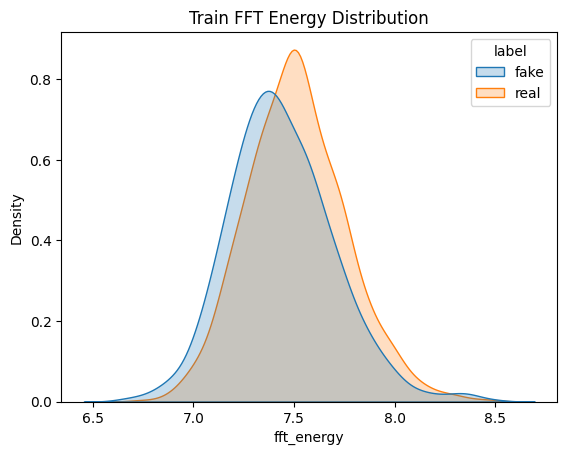

Validate FFT: 100%|██████████| 2000/2000 [00:05<00:00, 367.28it/s]


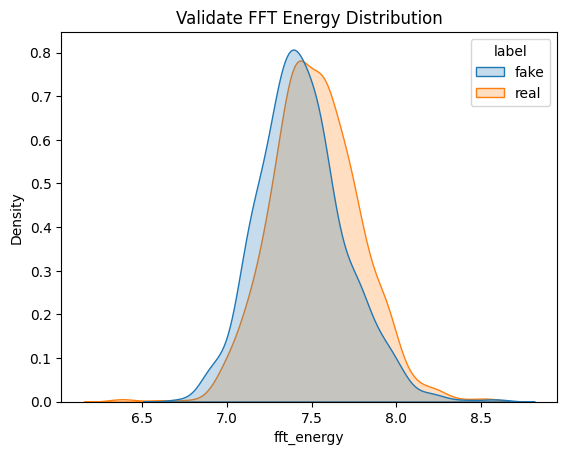

Test FFT: 100%|██████████| 2000/2000 [00:06<00:00, 318.23it/s]


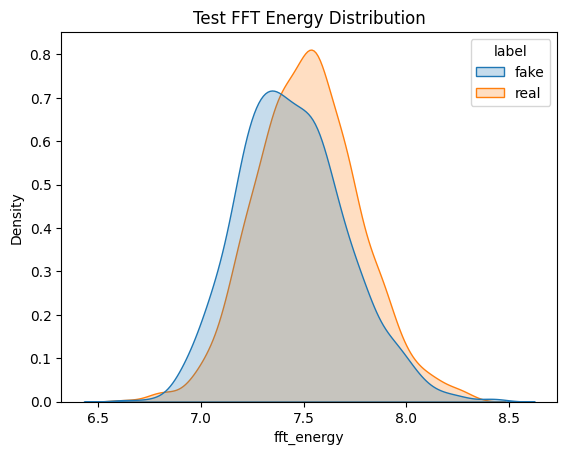

In [18]:
fft_energy_eda(train_df,"Train")
fft_energy_eda(val_df,"Validate")
fft_energy_eda(test_df,"Test")

In [19]:
! pip uninstall mediapipe -y
! pip install --upgrade mediapipe


Found existing installation: mediapipe 0.10.32
Uninstalling mediapipe-0.10.32:
  Successfully uninstalled mediapipe-0.10.32
  Using cached mediapipe-0.10.32-py3-none-win_amd64.whl.metadata (9.8 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached mediapipe-0.10.32-py3-none-win_amd64.whl (10.2 MB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

   ---------------------------------------- 0/2 [numpy]
    Uninstalling numpy-1.26.4:
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
xformers 0.0.30 requires torch==2.7.0, but you have torch 2.0.1+cu118 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import cv2
from tqdm import tqdm

def haar_face_presence_eda(df, name, sample=3000):
    """
    Fast face-presence EDA using Haar Cascade.
    Safe for large datasets (140k+ images).

    Parameters:
    - df: DataFrame with columns ['path', 'label']
    - name: dataset name (Train / Validation / Test)
    - sample: number of images to sample
    """

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    assert not face_cascade.empty(), "Haar cascade failed to load"

    temp = df.sample(sample, random_state=42)
    faces = []

    for path in tqdm(temp["path"], desc=f"{name} Haar face check"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            faces.append(0)
            continue

        detections = face_cascade.detectMultiScale(
            img,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(40, 40)
        )

        faces.append(1 if len(detections) > 0 else 0)

    temp = temp.copy()
    temp["face"] = faces

    print(f"\n{name} face presence rate:")
    print(temp.groupby("label")["face"].mean())


In [21]:
haar_face_presence_eda(train_df, "Train")
haar_face_presence_eda(val_df, "Validation")
haar_face_presence_eda(test_df, "Test")

Train Haar face check: 100%|██████████| 3000/3000 [00:17<00:00, 167.04it/s]



Train face presence rate:
label
fake    0.992563
real    0.948718
Name: face, dtype: float64


Validation Haar face check: 100%|██████████| 3000/3000 [00:14<00:00, 204.75it/s]



Validation face presence rate:
label
fake    0.995968
real    0.948413
Name: face, dtype: float64


Test Haar face check: 100%|██████████| 3000/3000 [00:15<00:00, 197.50it/s]


Test face presence rate:
label
fake    0.995968
real    0.943783
Name: face, dtype: float64
